# Protein Cofactor Binary Classification

Trains binary classifiers to predict which cofactors a protein uses based on its sequence.
Uses ESM2 protein language model for embeddings and logistic regression for classification.
One classifier per cofactor - each predicts presence/absence independently.
Automatically detects cofactors from CSV column headers - works with any cofactor set.

## Configuration

Set all parameters for reproducibility and customize the analysis.

### Important: Feature Engineering for Better Predictions

This notebook now uses **enriched features** that combine:
1. **ESM2 embeddings** (320 dims) - Deep evolutionary/structural patterns from protein language model
2. **Engineered sequence features** (~60 dims) - Explicit cofactor-binding signatures:
   - Amino acid composition (20 features)
   - Metal coordination residues (His, Cys, Asp, Glu)
   - Metal binding motifs (CxxC, HxxH patterns)
   - Charge properties (net charge, charge density)
   - Hydrophobicity patterns (GRAVY)
   - Redox-active residues (Cys, Met)
   - Aromatic clusters (important for electron transfer)
   - Metal coordination hotspots
   - Structural properties (proline/glycine, disulfide potential)
   - Terminal features (N/C-terminal metal coordination)

**No data leakage**: We do NOT use target cofactor labels as features - only intrinsic sequence properties.

In [79]:
# ===== CONFIGURATION PARAMETERS =====
# Set these parameters for your analysis

# Random seed for reproducibility
SEED = 42

# Input data path
DATA_PATH = r"C:\Users\d_gar\research\code_and_scripts\data_analysis\cofactor_PLM\ncbi_enzyme_cofactor_data.csv"

# Output directory (models and results will be saved in a subfolder with date and data filename)
BASE_OUTPUT_DIR = r"C:\Users\d_gar\research\code_and_scripts\data_analysis\cofactor_PLM\results"

# Optional filtering
REMOVE_NONE_COFACTORS = False  # Set to True to exclude proteins with no active cofactors

# Model parameters
TEST_SIZE = 0.2  # Fraction of data to use for testing (0.2 = 20% test, 80% train)
MAX_ITERATIONS = 5000  # Maximum iterations for logistic regression

# ESM2 model parameters
ESM_BATCH_SIZE = 4  # Batch size for embedding generation (reduce if GPU memory is low)
ESM_REPR_LAYER = 6  # ESM2 representation layer to use
TRUNCATE_LENGTH = 1022  # Maximum sequence length for ESM2

print("Configuration loaded successfully!")
print(f"Random Seed: {SEED}")
print(f"Data Path: {DATA_PATH}")
print(f"Base Output Directory: {BASE_OUTPUT_DIR}")
print(f"Test Size: {TEST_SIZE * 100}%")

Configuration loaded successfully!
Random Seed: 42
Data Path: C:\Users\d_gar\research\code_and_scripts\data_analysis\cofactor_PLM\ncbi_enzyme_cofactor_data.csv
Base Output Directory: C:\Users\d_gar\research\code_and_scripts\data_analysis\cofactor_PLM\results
Test Size: 20.0%


In [80]:
# Install required packages for ESM2 embeddings and machine learning
%pip install tqdm torch torchvision fair-esm scikit-learn matplotlib seaborn

Note: you may need to restart the kernel to use updated packages.


In [81]:
# Import libraries for data processing, embeddings, and machine learning

import os
import math
import json
import pickle
import random
from datetime import datetime
from pathlib import Path
from typing import List, Dict, Optional, Tuple

import numpy as np
import pandas as pd
from tqdm import tqdm

import torch
import esm

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    f1_score,
    top_k_accuracy_score
)
from sklearn.linear_model import LogisticRegression

import matplotlib.pyplot as plt
import seaborn as sns

print("All libraries imported successfully!")

All libraries imported successfully!


In [82]:
# Create organized output folder with date and data filename

# Extract filename from data path (without extension)
data_filename = Path(DATA_PATH).stem  # e.g., "ncbi_enzyme_cofactor_data"

# Create timestamp for folder name
timestamp = datetime.now().strftime("%Y%m%d")  # e.g., "20260512"

# Create output folder name
OUTPUT_FOLDER = os.path.join(BASE_OUTPUT_DIR, f"{timestamp}_{data_filename}")

# Create output directory if it doesn't exist
os.makedirs(OUTPUT_FOLDER, exist_ok=True)

# Define checkpoint and output paths
CHECKPOINT_DIR = os.path.join(OUTPUT_FOLDER, "checkpoints")
MODELS_DIR = os.path.join(OUTPUT_FOLDER, "models")
FIGURES_DIR = os.path.join(OUTPUT_FOLDER, "figures")
PREDICTIONS_DIR = os.path.join(OUTPUT_FOLDER, "predictions")

# Create subdirectories
for directory in [CHECKPOINT_DIR, MODELS_DIR, FIGURES_DIR, PREDICTIONS_DIR]:
    os.makedirs(directory, exist_ok=True)

print("=" * 80)
print("OUTPUT FOLDER STRUCTURE CREATED")
print("=" * 80)
print(f"Main output folder: {OUTPUT_FOLDER}")
print(f"  - Checkpoints: {CHECKPOINT_DIR}")
print(f"  - Models: {MODELS_DIR}")
print(f"  - Figures: {FIGURES_DIR}")
print(f"  - Predictions: {PREDICTIONS_DIR}")
print("=" * 80)

OUTPUT FOLDER STRUCTURE CREATED
Main output folder: C:\Users\d_gar\research\code_and_scripts\data_analysis\cofactor_PLM\results\20260512_ncbi_enzyme_cofactor_data
  - Checkpoints: C:\Users\d_gar\research\code_and_scripts\data_analysis\cofactor_PLM\results\20260512_ncbi_enzyme_cofactor_data\checkpoints
  - Models: C:\Users\d_gar\research\code_and_scripts\data_analysis\cofactor_PLM\results\20260512_ncbi_enzyme_cofactor_data\models
  - Figures: C:\Users\d_gar\research\code_and_scripts\data_analysis\cofactor_PLM\results\20260512_ncbi_enzyme_cofactor_data\figures
  - Predictions: C:\Users\d_gar\research\code_and_scripts\data_analysis\cofactor_PLM\results\20260512_ncbi_enzyme_cofactor_data\predictions


In [83]:
# Set random seeds for reproducibility and configure device (GPU/CPU)

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", DEVICE)
print(f"Random seed set to: {SEED}")

Using device: cpu
Random seed set to: 42


Input CSV format: protein sequences with binary cofactor labels.
Each cofactor column has 1 if protein uses it, 0 otherwise.
Processing converts binary labels to ideal_cofactor target variable.
Cofactor columns are automatically detected from CSV headers.

In [84]:
# Load CSV file containing protein sequences and binary cofactor labels

checkpoint_file = os.path.join(CHECKPOINT_DIR, "01_data_loaded.pkl")

if os.path.exists(checkpoint_file):
    print("=" * 80)
    print("CHECKPOINT FOUND: Loading previously processed data")
    print("=" * 80)
    with open(checkpoint_file, 'rb') as f:
        checkpoint_data = pickle.load(f)
    df_raw = checkpoint_data['df_raw']
    cofactor_cols = checkpoint_data['cofactor_cols']
    print(f"Loaded data from checkpoint: {checkpoint_file}")
else:
    print("=" * 80)
    print("LOADING DATA FROM CSV")
    print("=" * 80)
    df_raw = pd.read_csv(DATA_PATH)
    
    # Automatically detect cofactor columns (exclude non-cofactor columns)
    exclude_cols = {'header', 'sequence', 'protein_id'}
    cofactor_cols = [col for col in df_raw.columns if col not in exclude_cols]
    
    # Save checkpoint
    checkpoint_data = {
        'df_raw': df_raw,
        'cofactor_cols': cofactor_cols
    }
    with open(checkpoint_file, 'wb') as f:
        pickle.dump(checkpoint_data, f)
    print(f"Saved checkpoint: {checkpoint_file}")

print("\nRaw data shape:", df_raw.shape)
print("\nFirst few rows:")
print(df_raw.head())
print("\nColumn names:", df_raw.columns.tolist())
print(f"\nDetected cofactor columns: {cofactor_cols}")
print("\nCofactor distribution:")
print(df_raw[cofactor_cols].sum())

CHECKPOINT FOUND: Loading previously processed data
Loaded data from checkpoint: C:\Users\d_gar\research\code_and_scripts\data_analysis\cofactor_PLM\results\20260512_ncbi_enzyme_cofactor_data\checkpoints\01_data_loaded.pkl

Raw data shape: (2241, 7)

First few rows:
                                              header  \
0  NP_013752.1 copper chaperone CCS1 [Saccharomyc...   
1       pdb|1PF3|A Chain A, Blue copper oxidase cueO   
2  WP_415607860.1 copper homeostasis protein CutC...   
3  WP_289940195.1 copper homeostasis protein CutC...   
4      CAN5492343.1 copper oxidase [soil metagenome]   

                                            sequence  Cu  ATP  B12  CoA  NAD  
0  MTTNDTYEATYAIPMHCENCVNDIKACLKNVPGINSLNFDIEQQIM...   1    0    0    0    0  
1  AERPTLPIPDLLTTDARNRIQLTIGAGQSTFGGKTATTWGYNGNLL...   1    0    1    1    1  
2  MTIKIKEAAVDSADRAQEMIARGANRIELNARLDLGGITPDTRTII...   1    0    0    0    0  
3  MARRLGSERRTVTTAADPASLAEKSSTRARALVEICVDDLAGVLAA...   1    0    0    0    0  
4

In [85]:
# Process binary cofactor labels: rename columns and create ideal_cofactor target

checkpoint_file = os.path.join(CHECKPOINT_DIR, "02_data_processed.pkl")

if os.path.exists(checkpoint_file):
    print("=" * 80)
    print("CHECKPOINT FOUND: Loading previously processed dataset")
    print("=" * 80)
    with open(checkpoint_file, 'rb') as f:
        df = pickle.load(f)
    print(f"Loaded processed data from checkpoint: {checkpoint_file}")
else:
    print("=" * 80)
    print("PROCESSING DATA")
    print("=" * 80)
    
    df_raw = df_raw.rename(columns={'header': 'protein_id'})

    def determine_ideal_cofactor(row):
        active_cofactors = [col for col in cofactor_cols if row[col] == 1]
        
        if len(active_cofactors) == 0:
            return 'None'
        elif len(active_cofactors) == 1:
            return active_cofactors[0]
        else:
            return '_'.join(active_cofactors)

    df_raw['ideal_cofactor'] = df_raw.apply(determine_ideal_cofactor, axis=1)

    print("\nIdeal cofactor distribution:")
    print(df_raw['ideal_cofactor'].value_counts())

    print(f"\nRows with no active cofactors: {(df_raw['ideal_cofactor'] == 'None').sum()}")

    # Dynamically create activity columns for each cofactor
    for cofactor in cofactor_cols:
        activity_col = f'activity_{cofactor.lower()}'
        df_raw[activity_col] = df_raw[cofactor]

    # Build column list dynamically
    activity_cols = [f'activity_{cf.lower()}' for cf in cofactor_cols]
    df = df_raw[['protein_id', 'sequence', 'ideal_cofactor'] + activity_cols].copy()

    print("\nProcessed dataset shape:", df.shape)
    print("\nFirst few rows of processed data:")
    print(df.head())
    
    # Save checkpoint
    with open(checkpoint_file, 'wb') as f:
        pickle.dump(df, f)
    print(f"\nSaved checkpoint: {checkpoint_file}")

print("\nFinal processed dataset shape:", df.shape)

CHECKPOINT FOUND: Loading previously processed dataset
Loaded processed data from checkpoint: C:\Users\d_gar\research\code_and_scripts\data_analysis\cofactor_PLM\results\20260512_ncbi_enzyme_cofactor_data\checkpoints\02_data_processed.pkl

Final processed dataset shape: (2241, 8)


In [86]:
# Validate that dataset has required columns and check class distribution

required_cols = ["protein_id", "sequence", "ideal_cofactor"]
missing_required = [c for c in required_cols if c not in df.columns]
if missing_required:
    raise ValueError(f"Missing required columns: {missing_required}")

print("Dataset shape:", df.shape)
print("\nIdeal cofactor distribution:")
print(df["ideal_cofactor"].value_counts())

print(f"\nFinal dataset shape: {df.shape}")

Dataset shape: (2241, 8)

Ideal cofactor distribution:
ideal_cofactor
ATP               498
NAD               491
B12               485
CoA               446
Cu                319
Cu_B12_CoA_NAD      1
Cu_CoA              1
Name: count, dtype: int64

Final dataset shape: (2241, 8)


In [87]:
# Optional filtering: remove proteins with no active cofactors
# Controlled by REMOVE_NONE_COFACTORS parameter in configuration

checkpoint_file = os.path.join(CHECKPOINT_DIR, "03_data_filtered.pkl")

if os.path.exists(checkpoint_file):
    print("=" * 80)
    print("CHECKPOINT FOUND: Loading previously filtered dataset")
    print("=" * 80)
    with open(checkpoint_file, 'rb') as f:
        df = pickle.load(f)
    print(f"Loaded filtered data from checkpoint: {checkpoint_file}")
else:
    print("=" * 80)
    print("FILTERING DATA")
    print("=" * 80)
    
    if REMOVE_NONE_COFACTORS:
        df_before = df.shape[0]
        df = df[df['ideal_cofactor'] != 'None'].copy()
        df.reset_index(drop=True, inplace=True)
        print(f"Removed {df_before - df.shape[0]} proteins with no active cofactors")
        print(f"New dataset shape: {df.shape}")
        print("\nNew cofactor distribution:")
        print(df["ideal_cofactor"].value_counts())
    else:
        print("Keeping all data including negative examples (proteins with no active cofactors)")
        print(f"Dataset shape: {df.shape}")
        print("\nCofactor distribution (including 'None' for negative examples):")
        print(df["ideal_cofactor"].value_counts())
    
    # Save checkpoint
    with open(checkpoint_file, 'wb') as f:
        pickle.dump(df, f)
    print(f"\nSaved checkpoint: {checkpoint_file}")

CHECKPOINT FOUND: Loading previously filtered dataset
Loaded filtered data from checkpoint: C:\Users\d_gar\research\code_and_scripts\data_analysis\cofactor_PLM\results\20260512_ncbi_enzyme_cofactor_data\checkpoints\03_data_filtered.pkl


In [88]:
# Clean protein sequences: remove invalid characters, ensure valid amino acids only

checkpoint_file = os.path.join(CHECKPOINT_DIR, "04_sequences_cleaned.pkl")

if os.path.exists(checkpoint_file):
    print("=" * 80)
    print("CHECKPOINT FOUND: Loading previously cleaned sequences")
    print("=" * 80)
    with open(checkpoint_file, 'rb') as f:
        df = pickle.load(f)
    print(f"Loaded cleaned data from checkpoint: {checkpoint_file}")
else:
    print("=" * 80)
    print("CLEANING SEQUENCES")
    print("=" * 80)
    
    VALID_AA = set(list("ACDEFGHIKLMNPQRSTVWYUXBZJO"))

    def clean_sequence(seq: str) -> str:
        seq = str(seq).strip().upper()
        seq = seq.replace(" ", "")
        seq = "".join([aa for aa in seq if aa in VALID_AA])
        return seq

    df["sequence"] = df["sequence"].apply(clean_sequence)

    df = df[df["sequence"].str.len() >= 20].copy()
    df.reset_index(drop=True, inplace=True)

    print("Cleaned dataset shape:", df.shape)
    
    # Save checkpoint
    with open(checkpoint_file, 'wb') as f:
        pickle.dump(df, f)
    print(f"Saved checkpoint: {checkpoint_file}")

print("\nFinal dataset shape after cleaning:", df.shape)

CHECKPOINT FOUND: Loading previously cleaned sequences
Loaded cleaned data from checkpoint: C:\Users\d_gar\research\code_and_scripts\data_analysis\cofactor_PLM\results\20260512_ncbi_enzyme_cofactor_data\checkpoints\04_sequences_cleaned.pkl

Final dataset shape after cleaning: (2241, 8)


Note: Using classical ML classifier (Logistic Regression) first before trying deep learning.
Works well on small datasets, easier to debug, and less prone to overfitting.
Sequence embeddings from ESM2 provide biological context.

In [89]:
# Load pretrained ESM2 model for generating protein sequence embeddings
# Using smaller 8M parameter model for faster processing

model, alphabet = esm.pretrained.esm2_t6_8M_UR50D()
batch_converter = alphabet.get_batch_converter()

model = model.to(DEVICE)
model.eval()

print("Loaded ESM model.")

Loaded ESM model.


In [90]:
# Define function to generate fixed-length embeddings from protein sequences
# Uses mean pooling over residue embeddings from ESM2 model

@torch.no_grad()
def embed_sequences_esm(
    sequences: List[str],
    ids: Optional[List[str]] = None,
    batch_size: int = 8,
    repr_layer: int = 6,
    truncate_len: int = 1022
) -> np.ndarray:
    if ids is None:
        ids = [f"seq_{i}" for i in range(len(sequences))]

    data = [(ids[i], sequences[i][:truncate_len]) for i in range(len(sequences))]
    all_embeddings = []

    for start in tqdm(range(0, len(data), batch_size), desc="Embedding sequences"):
        batch = data[start:start+batch_size]
        labels, strs, tokens = batch_converter(batch)
        tokens = tokens.to(DEVICE)

        out = model(tokens, repr_layers=[repr_layer], return_contacts=False)
        token_representations = out["representations"][repr_layer]

        for i, seq in enumerate(strs):
            seq_len = len(seq)
            residue_embeddings = token_representations[i, 1:seq_len+1]
            pooled = residue_embeddings.mean(0).cpu().numpy()
            all_embeddings.append(pooled)

    return np.vstack(all_embeddings)

In [91]:
# Generate embeddings for all protein sequences in the dataset

checkpoint_file = os.path.join(CHECKPOINT_DIR, "05_embeddings.npy")

if os.path.exists(checkpoint_file):
    print("=" * 80)
    print("CHECKPOINT FOUND: Loading previously generated embeddings")
    print("=" * 80)
    X_seq = np.load(checkpoint_file)
    print(f"Loaded embeddings from checkpoint: {checkpoint_file}")
    print("Sequence embedding matrix shape:", X_seq.shape)
else:
    print("=" * 80)
    print("GENERATING ESM2 EMBEDDINGS")
    print("=" * 80)
    print("This may take some time depending on dataset size...")
    
    protein_ids = df["protein_id"].tolist()
    sequences = df["sequence"].tolist()

    X_seq = embed_sequences_esm(
        sequences=sequences,
        ids=protein_ids,
        batch_size=ESM_BATCH_SIZE,
        repr_layer=ESM_REPR_LAYER
    )

    print("\nSequence embedding matrix shape:", X_seq.shape)
    
    # Save checkpoint
    np.save(checkpoint_file, X_seq)
    print(f"Saved embeddings to checkpoint: {checkpoint_file}")

print(f"\nEmbeddings ready: {X_seq.shape[0]} proteins, {X_seq.shape[1]} dimensions")

CHECKPOINT FOUND: Loading previously generated embeddings
Loaded embeddings from checkpoint: C:\Users\d_gar\research\code_and_scripts\data_analysis\cofactor_PLM\results\20260512_ncbi_enzyme_cofactor_data\checkpoints\05_embeddings.npy
Sequence embedding matrix shape: (2241, 320)

Embeddings ready: 2241 proteins, 320 dimensions


## Feature Engineering for Cofactor Binding

Extract biologically relevant sequence features that correlate with cofactor binding patterns. These features capture properties like metal coordination residues, hydrophobicity, charge distribution, and binding motifs.

In [92]:
# Engineer comprehensive sequence-based features for cofactor binding prediction

checkpoint_file = os.path.join(CHECKPOINT_DIR, "05b_sequence_features.pkl")

if os.path.exists(checkpoint_file):
    print("=" * 80)
    print("CHECKPOINT FOUND: Loading previously engineered features")
    print("=" * 80)
    with open(checkpoint_file, 'rb') as f:
        feature_data = pickle.load(f)
    X_features = feature_data['features']
    feature_names = feature_data['feature_names']
    print(f"Loaded {X_features.shape[1]} engineered features from checkpoint")
    print(f"Checkpoint: {checkpoint_file}")
else:
    print("=" * 80)
    print("ENGINEERING SEQUENCE FEATURES FOR COFACTOR BINDING")
    print("=" * 80)
    
    feature_list = []
    feature_names = []
    
    sequences = df['sequence'].values
    
    # Define amino acid groups
    aa_groups = {
        'hydrophobic': 'AILMFWYV',
        'polar': 'STNQ',
        'positive': 'KR',
        'negative': 'DE',
        'aromatic': 'FWY',
        'aliphatic': 'ILV',
        'small': 'AGSV',
        'tiny': 'AGS',
        # Metal coordination residues - CRITICAL for cofactor binding
        'metal_coord': 'HCDE',  # His, Cys, Asp, Glu
        'cysteine': 'C',
        'histidine': 'H',
        'aspartate': 'D',
        'glutamate': 'E',
        'methionine': 'M',  # Can coordinate soft metals
        'tyrosine': 'Y',  # Can be involved in redox
        'tryptophan': 'W',  # Electron transfer
    }
    
    print("Extracting features from sequences...")
    for seq in tqdm(sequences, desc="Feature extraction"):
        features = []
        seq_len = len(seq)
        
        # 1. SEQUENCE LENGTH (normalized)
        features.append(seq_len / 1000.0)
        if len(feature_names) < len(features):
            feature_names.append('seq_length_norm')
        
        # 2. AMINO ACID COMPOSITION (20 features)
        aa_standard = 'ACDEFGHIKLMNPQRSTVWY'
        for aa in aa_standard:
            features.append(seq.count(aa) / seq_len)
            if len(feature_names) < len(features):
                feature_names.append(f'aa_comp_{aa}')
        
        # 3. AMINO ACID GROUP COMPOSITION
        for group_name, group_aas in aa_groups.items():
            group_frac = sum(seq.count(aa) for aa in group_aas) / seq_len
            features.append(group_frac)
            if len(feature_names) < len(features):
                feature_names.append(f'group_{group_name}')
        
        # 4. METAL BINDING MOTIFS AND PATTERNS
        # Cys-X-X-Cys pattern (common in metal binding)
        cxxc_count = 0
        for i in range(len(seq) - 3):
            if seq[i] == 'C' and seq[i+3] == 'C':
                cxxc_count += 1
        features.append(cxxc_count / max(1, seq_len - 3))
        if len(feature_names) < len(features):
            feature_names.append('motif_cxxc')
        
        # His-X-X-His pattern
        hxxh_count = 0
        for i in range(len(seq) - 3):
            if seq[i] == 'H' and seq[i+3] == 'H':
                hxxh_count += 1
        features.append(hxxh_count / max(1, seq_len - 3))
        if len(feature_names) < len(features):
            feature_names.append('motif_hxxh')
        
        # Cys-Cys (adjacent)
        cc_count = seq.count('CC')
        features.append(cc_count / max(1, seq_len - 1))
        if len(feature_names) < len(features):
            feature_names.append('motif_cc')
        
        # 5. CHARGE PROPERTIES
        # Net charge
        positive_count = sum(seq.count(aa) for aa in 'KR')
        negative_count = sum(seq.count(aa) for aa in 'DE')
        net_charge = (positive_count - negative_count) / seq_len
        features.append(net_charge)
        if len(feature_names) < len(features):
            feature_names.append('net_charge')
        
        # Charge density
        charge_density = (positive_count + negative_count) / seq_len
        features.append(charge_density)
        if len(feature_names) < len(features):
            feature_names.append('charge_density')
        
        # 6. HYDROPHOBICITY
        # Grand average of hydropathy (GRAVY) - simplified
        hydrophobic = sum(seq.count(aa) for aa in 'AILMFWYV')
        hydrophilic = sum(seq.count(aa) for aa in 'RKDENQ')
        gravy_approx = (hydrophobic - hydrophilic) / seq_len
        features.append(gravy_approx)
        if len(feature_names) < len(features):
            feature_names.append('gravy_approx')
        
        # 7. MOLECULAR WEIGHT ESTIMATE (simplified)
        # Average MW per residue ≈ 110 Da
        mw_estimate = seq_len * 110 / 50000  # Normalized by ~50kDa
        features.append(mw_estimate)
        if len(feature_names) < len(features):
            feature_names.append('mol_weight_norm')
        
        # 8. AROMATIC CLUSTERS (important for electron transfer cofactors)
        aromatic_aas = 'FWY'
        aromatic_cluster = 0
        for i in range(len(seq) - 2):
            window = seq[i:i+3]
            if sum(aa in aromatic_aas for aa in window) >= 2:
                aromatic_cluster += 1
        features.append(aromatic_cluster / max(1, seq_len - 2))
        if len(feature_names) < len(features):
            feature_names.append('aromatic_clusters')
        
        # 9. METAL COORDINATION HOTSPOTS
        # Windows with high concentration of metal-coordinating residues
        metal_coords = 'HCDE'
        metal_hotspots = 0
        window_size = 10
        for i in range(len(seq) - window_size + 1):
            window = seq[i:i+window_size]
            metal_count = sum(aa in metal_coords for aa in window)
            if metal_count >= 4:  # At least 4 coordinating residues in 10 AA
                metal_hotspots += 1
        features.append(metal_hotspots / max(1, seq_len - window_size + 1))
        if len(feature_names) < len(features):
            feature_names.append('metal_hotspots')
        
        # 10. REDOX-ACTIVE RESIDUE PATTERNS
        # Cys and Met can be involved in redox chemistry
        redox_residues = seq.count('C') + seq.count('M')
        features.append(redox_residues / seq_len)
        if len(feature_names) < len(features):
            feature_names.append('redox_residues')
        
        # 11. DISULFIDE BOND POTENTIAL (even number of Cys)
        cys_count = seq.count('C')
        features.append(cys_count)
        if len(feature_names) < len(features):
            feature_names.append('cysteine_count')
        
        features.append(1 if cys_count % 2 == 0 and cys_count > 0 else 0)
        if len(feature_names) < len(features):
            feature_names.append('disulfide_potential')
        
        # 12. PROLINE CONTENT (affects flexibility)
        proline_frac = seq.count('P') / seq_len
        features.append(proline_frac)
        if len(feature_names) < len(features):
            feature_names.append('proline_content')
        
        # 13. GLYCINE CONTENT (affects flexibility)
        glycine_frac = seq.count('G') / seq_len
        features.append(glycine_frac)
        if len(feature_names) < len(features):
            feature_names.append('glycine_content')
        
        # 14. N-TERMINAL AND C-TERMINAL COMPOSITION (first/last 20 residues)
        n_term = seq[:min(20, seq_len)]
        c_term = seq[-min(20, seq_len):]
        
        # Metal coordinating residues at termini
        n_term_metal = sum(aa in 'HCDE' for aa in n_term) / len(n_term)
        c_term_metal = sum(aa in 'HCDE' for aa in c_term) / len(c_term)
        features.append(n_term_metal)
        features.append(c_term_metal)
        if len(feature_names) < len(features) - 1:
            feature_names.append('n_term_metal_coord')
            feature_names.append('c_term_metal_coord')
        
        feature_list.append(features)
    
    X_features = np.array(feature_list)
    
    print(f"\n✓ Engineered {X_features.shape[1]} features")
    print(f"  - Sequence properties: length, MW")
    print(f"  - Amino acid composition: 20 standard AAs")
    print(f"  - Chemical groups: {len(aa_groups)} groups")
    print(f"  - Metal binding motifs: CxxC, HxxH, CC")
    print(f"  - Charge properties: net charge, density")
    print(f"  - Hydrophobicity: GRAVY approximation")
    print(f"  - Cofactor-relevant: metal hotspots, redox residues, aromatic clusters")
    print(f"  - Structural: proline/glycine content, disulfide potential")
    print(f"  - Terminal features: N-term and C-term metal coordination")
    
    # Standardize features
    from sklearn.preprocessing import StandardScaler
    scaler = StandardScaler()
    X_features_scaled = scaler.fit_transform(X_features)
    
    # Save checkpoint
    feature_data = {
        'features': X_features_scaled,
        'feature_names': feature_names,
        'scaler': scaler,
        'raw_features': X_features
    }
    with open(checkpoint_file, 'wb') as f:
        pickle.dump(feature_data, f)
    print(f"\nSaved features to checkpoint: {checkpoint_file}")
    
    X_features = X_features_scaled

print(f"\n✓ Feature matrix: {X_features.shape[0]} proteins × {X_features.shape[1]} features")
print(f"  Feature names: {', '.join(feature_names[:10])}... (showing first 10)")

CHECKPOINT FOUND: Loading previously engineered features
Loaded 53 engineered features from checkpoint
Checkpoint: C:\Users\d_gar\research\code_and_scripts\data_analysis\cofactor_PLM\results\20260512_ncbi_enzyme_cofactor_data\checkpoints\05b_sequence_features.pkl

✓ Feature matrix: 2241 proteins × 53 features
  Feature names: seq_length_norm, aa_comp_A, aa_comp_C, aa_comp_D, aa_comp_E, aa_comp_F, aa_comp_G, aa_comp_H, aa_comp_I, aa_comp_K... (showing first 10)


In [93]:
# Combine ESM embeddings with engineered features

print("=" * 80)
print("COMBINING FEATURES")
print("=" * 80)

X_combined = np.hstack([X_seq, X_features])

print(f"ESM2 embeddings:      {X_seq.shape[1]} features")
print(f"Engineered features:  {X_features.shape[1]} features")
print(f"Combined matrix:      {X_combined.shape}")
print(f"\n✓ Total feature space: {X_combined.shape[1]} dimensions")
print(f"  = {X_seq.shape[1]} (semantic/structural from ESM2)")
print(f"  + {X_features.shape[1]} (sequence properties for cofactor binding)")
print("\nThis combined representation captures both:")
print("  1. Deep evolutionary patterns (from protein language model)")
print("  2. Explicit cofactor-binding signatures (metal coordination, charge, etc.)")

COMBINING FEATURES
ESM2 embeddings:      320 features
Engineered features:  53 features
Combined matrix:      (2241, 373)

✓ Total feature space: 373 dimensions
  = 320 (semantic/structural from ESM2)
  + 53 (sequence properties for cofactor binding)

This combined representation captures both:
  1. Deep evolutionary patterns (from protein language model)
  2. Explicit cofactor-binding signatures (metal coordination, charge, etc.)


## Binary Classification Approach

Train separate binary classifiers for each cofactor:
- One model per cofactor: Does this protein use [cofactor]? (Yes/No)
- Number of classifiers = number of cofactors in your CSV

Data leakage prevention:
- Only use sequence embeddings as input features
- Binary labels from CSV are targets (what we predict), not input features
- No activity columns passed to models

Advantages:
- Balanced classes for each classifier
- Can handle multi-cofactor proteins naturally
- Realistic predictions based only on sequence patterns
- Automatically adapts to any cofactor set in CSV headers

In [94]:
# Create binary labels for each cofactor from original CSV columns

print("=== CREATING BINARY LABELS (NO LEAKAGE) ===\n")

# Use the dynamically detected cofactor columns
cofactor_names = cofactor_cols

# Ensure df_raw is available (it should be from checkpoint loading)
if 'df_raw' not in dir():
    print("Loading df_raw from checkpoint...")
    checkpoint_file_raw = os.path.join(CHECKPOINT_DIR, "01_data_loaded.pkl")
    if os.path.exists(checkpoint_file_raw):
        with open(checkpoint_file_raw, 'rb') as f:
            checkpoint_data = pickle.load(f)
        df_raw = checkpoint_data['df_raw']
    else:
        raise ValueError("df_raw not found. Please run the data loading cell first.")

binary_labels = {}
for cofactor in cofactor_names:
    binary_labels[cofactor] = df_raw.loc[df.index, cofactor].values
    
print("Binary label distribution:")
for cofactor in cofactor_names:
    n_positive = binary_labels[cofactor].sum()
    n_negative = len(binary_labels[cofactor]) - n_positive
    print(f"  {cofactor}: {n_positive} positive, {n_negative} negative")

print(f"\nLabels created from original binary columns ({', '.join(cofactor_names)})")
print("These tell us which cofactors each protein actually uses")

=== CREATING BINARY LABELS (NO LEAKAGE) ===

Binary label distribution:
  Cu: 321 positive, 1920 negative
  ATP: 498 positive, 1743 negative
  B12: 486 positive, 1755 negative
  CoA: 448 positive, 1793 negative
  NAD: 492 positive, 1749 negative

Labels created from original binary columns (Cu, ATP, B12, CoA, NAD)
These tell us which cofactors each protein actually uses


In [95]:
# Train binary classifiers using ONLY sequence embeddings (no activity features)

checkpoint_file = os.path.join(CHECKPOINT_DIR, "06_binary_classifiers.pkl")

# Check if checkpoint exists and is valid for current feature dimensions
checkpoint_valid = False
if os.path.exists(checkpoint_file):
    print("=" * 80)
    print("CHECKPOINT FOUND: Validating feature dimensions...")
    print("=" * 80)
    try:
        with open(checkpoint_file, 'rb') as f:
            checkpoint_data = pickle.load(f)
        
        # Validate that checkpoint models match current feature dimensions
        first_cofactor = list(checkpoint_data['classifiers'].keys())[0]
        expected_features = checkpoint_data['classifiers'][first_cofactor].n_features_in_
        current_features = X_combined.shape[1]
        
        if expected_features == current_features:
            binary_classifiers = checkpoint_data['classifiers']
            binary_results = checkpoint_data['results']
            binary_labels = checkpoint_data['labels']
            cofactor_names = checkpoint_data['cofactor_names']
            checkpoint_valid = True
            print(f"✓ Checkpoint valid: {expected_features} features match current {current_features}")
            print(f"✓ Loaded {len(binary_classifiers)} trained classifiers")
            print(f"  Cofactor names: {', '.join(cofactor_names)}")
        else:
            print(f"✗ Checkpoint incompatible:")
            print(f"  - Checkpoint models expect: {expected_features} features")
            print(f"  - Current feature matrix has: {current_features} features")
            print(f"  - Will retrain models with current features")
    except Exception as e:
        print(f"✗ Error loading checkpoint: {e}")
        print(f"  - Will retrain models")

if not checkpoint_valid:
    print("=" * 80)
    print("TRAINING BINARY CLASSIFIERS WITH ENRICHED FEATURES")
    print("=" * 80)
    print("FEATURE ENGINEERING:")
    print(f"  - Using X_combined (embeddings + sequence features)")
    print(f"  - Feature matrix shape: {X_combined.shape}")
    print(f"  - Includes: ESM2 embeddings + cofactor-binding signatures")
    print("  - NO activity columns included (data leakage prevention)")
    print("  - NO target cofactor labels used as features\n")

    # Set cofactor_names from cofactor_cols
    cofactor_names = cofactor_cols

    # Create binary labels
    binary_labels = {}
    for cofactor in cofactor_names:
        binary_labels[cofactor] = df_raw.loc[df.index, cofactor].values

    binary_classifiers = {}
    binary_results = {}

    for cofactor in cofactor_names:
        print(f"Training {cofactor} classifier...")
        
        y_binary = binary_labels[cofactor]
        
        X_train_bin, X_test_bin, y_train_bin, y_test_bin = train_test_split(
            X_combined,  # Use combined features instead of just X_seq
            y_binary,
            test_size=TEST_SIZE,
            random_state=SEED,
            stratify=y_binary if len(np.unique(y_binary)) > 1 and min(np.bincount(y_binary)) >= 2 else None
        )
        
        clf_binary = LogisticRegression(
            max_iter=MAX_ITERATIONS,
            class_weight='balanced',
            random_state=SEED
        )
        clf_binary.fit(X_train_bin, y_train_bin)
        
        y_pred_bin = clf_binary.predict(X_test_bin)
        y_proba_bin = clf_binary.predict_proba(X_test_bin)
        
        accuracy = accuracy_score(y_test_bin, y_pred_bin)
        f1 = f1_score(y_test_bin, y_pred_bin, average='binary', zero_division=0)
        
        binary_classifiers[cofactor] = clf_binary
        binary_results[cofactor] = {
            'accuracy': accuracy,
            'f1': f1,
            'y_test': y_test_bin,
            'y_pred': y_pred_bin,
            'y_proba': y_proba_bin
        }
        
        print(f"  {cofactor}: Accuracy={accuracy:.3f}, F1={f1:.3f}")

    print("\nAll classifiers trained using enriched feature set")
    
    # Save checkpoint
    checkpoint_data = {
        'classifiers': binary_classifiers,
        'results': binary_results,
        'labels': binary_labels,
        'cofactor_names': cofactor_names
    }
    with open(checkpoint_file, 'wb') as f:
        pickle.dump(checkpoint_data, f)
    print(f"\nSaved checkpoint: {checkpoint_file}")

print(f"\nTotal classifiers trained: {len(binary_classifiers)}")


CHECKPOINT FOUND: Validating feature dimensions...
✓ Checkpoint valid: 373 features match current 373
✓ Loaded 5 trained classifiers
  Cofactor names: Cu, ATP, B12, CoA, NAD

Total classifiers trained: 5


In [96]:
# Detailed evaluation metrics for each binary classifier

print("=== DETAILED PERFORMANCE BY COFACTOR ===\n")

for cofactor in cofactor_names:
    results = binary_results[cofactor]
    print(f"\n{cofactor} Classifier:")
    print("=" * 40)
    print(classification_report(
        results['y_test'], 
        results['y_pred'],
        target_names=['No ' + cofactor, 'Has ' + cofactor],
        zero_division=0
    ))
    
    cm_binary = confusion_matrix(results['y_test'], results['y_pred'])
    print(f"Confusion Matrix:")
    print(f"  True Neg: {cm_binary[0,0]}, False Pos: {cm_binary[0,1]}")
    print(f"  False Neg: {cm_binary[1,0]}, True Pos: {cm_binary[1,1]}")

print("\n" + "=" * 60)
print("SUMMARY OF BINARY CLASSIFICATION APPROACH:")
print("=" * 60)
for cofactor in cofactor_names:
    results = binary_results[cofactor]
    print(f"{cofactor}: Acc={results['accuracy']:.3f}, F1={results['f1']:.3f}")

=== DETAILED PERFORMANCE BY COFACTOR ===


Cu Classifier:
              precision    recall  f1-score   support

       No Cu       0.99      0.99      0.99       385
      Has Cu       0.92      0.95      0.94        64

    accuracy                           0.98       449
   macro avg       0.96      0.97      0.96       449
weighted avg       0.98      0.98      0.98       449

Confusion Matrix:
  True Neg: 380, False Pos: 5
  False Neg: 3, True Pos: 61

ATP Classifier:
              precision    recall  f1-score   support

      No ATP       1.00      0.99      0.99       349
     Has ATP       0.96      1.00      0.98       100

    accuracy                           0.99       449
   macro avg       0.98      0.99      0.99       449
weighted avg       0.99      0.99      0.99       449

Confusion Matrix:
  True Neg: 345, False Pos: 4
  False Neg: 0, True Pos: 100

B12 Classifier:
              precision    recall  f1-score   support

      No B12       0.99      0.98      0.99 

In [97]:
# Diagnostic: Check dataset size and test set composition

print("=" * 80)
print("DATASET DIAGNOSTIC - Checking for Overfitting Issues")
print("=" * 80)

print(f"\nTotal dataset size: {len(df)} proteins")
print(f"Train/Test split: {TEST_SIZE*100:.0f}% test, {(1-TEST_SIZE)*100:.0f}% train")

print("\nPer-cofactor class distribution and test set size:")
print("-" * 80)
for cofactor in cofactor_names:
    results = binary_results[cofactor]
    n_test_samples = len(results['y_test'])
    n_positive_test = results['y_test'].sum()
    n_negative_test = n_test_samples - n_positive_test
    
    # Total positive/negative in full dataset
    y_full = binary_labels[cofactor]
    n_positive_total = y_full.sum()
    n_negative_total = len(y_full) - n_positive_total
    
    print(f"\n{cofactor}:")
    print(f"  Full dataset: {n_positive_total} positive, {n_negative_total} negative")
    print(f"  Test set: {n_test_samples} samples ({n_positive_test} positive, {n_negative_test} negative)")
    print(f"  Accuracy: {results['accuracy']:.3f}, F1: {results['f1']:.3f}")
    
print("\n" + "=" * 80)
print("OVERFITTING INDICATORS:")
print("=" * 80)
print("- Very small test sets (< 20 samples) can give misleadingly high scores")
print("- Perfect or near-perfect AUC (>0.98) often indicates overfitting")
print("- Severe class imbalance (e.g., 95/5 split) makes random guessing look good")
print("\nPossible solutions:")
print("1. Add stronger regularization (increase C penalty)")
print("2. Use cross-validation instead of single train/test split")
print("3. Get more training data")
print("4. Use simpler features or dimensionality reduction")

DATASET DIAGNOSTIC - Checking for Overfitting Issues

Total dataset size: 2241 proteins
Train/Test split: 20% test, 80% train

Per-cofactor class distribution and test set size:
--------------------------------------------------------------------------------

Cu:
  Full dataset: 321 positive, 1920 negative
  Test set: 449 samples (64 positive, 385 negative)
  Accuracy: 0.982, F1: 0.938

ATP:
  Full dataset: 498 positive, 1743 negative
  Test set: 449 samples (100 positive, 349 negative)
  Accuracy: 0.991, F1: 0.980

B12:
  Full dataset: 486 positive, 1755 negative
  Test set: 449 samples (97 positive, 352 negative)
  Accuracy: 0.980, F1: 0.955

CoA:
  Full dataset: 448 positive, 1793 negative
  Test set: 449 samples (90 positive, 359 negative)
  Accuracy: 0.978, F1: 0.946

NAD:
  Full dataset: 492 positive, 1749 negative
  Test set: 449 samples (99 positive, 350 negative)
  Accuracy: 0.987, F1: 0.969

OVERFITTING INDICATORS:
- Very small test sets (< 20 samples) can give misleadingly h

## Addressing Overfitting with Stronger Regularization

The near-perfect ROC curves (AUC > 0.98) suggest overfitting. ESM2 embeddings are extremely powerful and can memorize training patterns. Solutions:

1. **Increase regularization strength**: Lower the `C` parameter in LogisticRegression (default C=1.0, try C=0.01-0.1 for stronger penalty)
2. **Cross-validation**: Use k-fold CV to get more realistic performance estimates
3. **Simpler models**: Consider reducing dimensionality or using fewer features

Below: Retrain with stronger L2 regularization to prevent memorization.

In [98]:
# Train with stronger regularization to reduce overfitting

print("=" * 80)
print("TRAINING WITH REGULARIZATION - Preventing Overfitting")
print("=" * 80)
print("\nComparing different regularization strengths:")
print("  C = 1.0:  Default (weak regularization - may overfit)")
print("  C = 0.1:  Moderate regularization")
print("  C = 0.01: Strong regularization (prevents memorization)")
print("\nTraining models with C=0.01 for more generalizable predictions...")
print()

# Test different C values
regularized_classifiers = {}
regularized_results = {}
C_VALUES_TO_TEST = [0.01, 0.1, 1.0]  # Strong to weak regularization

for C_val in C_VALUES_TO_TEST:
    print(f"\n{'='*80}")
    print(f"REGULARIZATION STRENGTH: C = {C_val}")
    print(f"{'='*80}")
    
    temp_classifiers = {}
    temp_results = {}
    
    for cofactor in cofactor_names:
        y_binary = binary_labels[cofactor]
        
        # Use same train/test split as before for fair comparison
        X_train_bin, X_test_bin, y_train_bin, y_test_bin = train_test_split(
            X_combined,
            y_binary,
            test_size=TEST_SIZE,
            random_state=SEED,
            stratify=y_binary if len(np.unique(y_binary)) > 1 and min(np.bincount(y_binary)) >= 2 else None
        )
        
        # Train with specified regularization
        clf = LogisticRegression(
            C=C_val,  # Lower C = stronger regularization
            max_iter=MAX_ITERATIONS,
            class_weight='balanced',
            random_state=SEED,
            penalty='l2'  # L2 regularization (Ridge)
        )
        clf.fit(X_train_bin, y_train_bin)
        
        y_pred = clf.predict(X_test_bin)
        y_proba = clf.predict_proba(X_test_bin)[:, 1]
        
        # Calculate metrics
        from sklearn.metrics import roc_auc_score
        accuracy = accuracy_score(y_test_bin, y_pred)
        f1 = f1_score(y_test_bin, y_pred, average='binary', zero_division=0)
        auc = roc_auc_score(y_test_bin, y_proba)
        
        temp_classifiers[cofactor] = clf
        temp_results[cofactor] = {
            'accuracy': accuracy,
            'f1': f1,
            'auc': auc,
            'y_test': y_test_bin,
            'y_pred': y_pred,
            'y_proba': y_proba
        }
        
        print(f"  {cofactor}: Acc={accuracy:.3f}, F1={f1:.3f}, AUC={auc:.3f}")
    
    if C_val == 0.01:  # Save the strongly regularized models
        regularized_classifiers = temp_classifiers
        regularized_results = temp_results

print("\n" + "=" * 80)
print("COMPARISON: Original (C=1.0) vs Regularized (C=0.01)")
print("=" * 80)
print(f"{'Cofactor':<10} {'Orig AUC':<12} {'Reg AUC':<12} {'Change':<12}")
print("-" * 80)
for cofactor in cofactor_names:
    orig_auc = roc_data[cofactor]['auc']
    reg_auc = regularized_results[cofactor]['auc']
    change = reg_auc - orig_auc
    print(f"{cofactor:<10} {orig_auc:>10.4f}   {reg_auc:>10.4f}   {change:>+10.4f}")

print("\n" + "=" * 80)
print("INTERPRETATION:")
print("=" * 80)
print("If regularized AUC drops significantly (e.g., from 0.99 to 0.85):")
print("  → Original model was overfitting/memorizing training data")
print("  → Regularized model is more realistic for new proteins")
print("\nIf regularized AUC stays high (> 0.90):")
print("  → Task may genuinely be easy (well-separated classes)")
print("  → ESM2 embeddings capture true biological signal")
print("\nRecommendation: Use regularized models (C=0.01) for production predictions")

TRAINING WITH REGULARIZATION - Preventing Overfitting

Comparing different regularization strengths:
  C = 1.0:  Default (weak regularization - may overfit)
  C = 0.1:  Moderate regularization
  C = 0.01: Strong regularization (prevents memorization)

Training models with C=0.01 for more generalizable predictions...


REGULARIZATION STRENGTH: C = 0.01
  Cu: Acc=0.924, F1=0.767, AUC=0.973
  ATP: Acc=0.940, F1=0.872, AUC=0.984
  B12: Acc=0.906, F1=0.796, AUC=0.952
  CoA: Acc=0.918, F1=0.816, AUC=0.954
  NAD: Acc=0.878, F1=0.756, AUC=0.938

REGULARIZATION STRENGTH: C = 0.1


c:\Users\d_gar\OneDrive\Documents\research_docs\papers\PPIX\PPIX Docs V8\.conda\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\d_gar\OneDrive\Documents\research_docs\papers\PPIX\PPIX Docs V8\.conda\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\d_gar\OneDrive\Documents\research_docs\papers\PPIX\PPIX Docs V8\.conda\Lib\site-package

  Cu: Acc=0.964, F1=0.884, AUC=0.992
  ATP: Acc=0.969, F1=0.933, AUC=0.998
  B12: Acc=0.955, F1=0.903, AUC=0.989
  CoA: Acc=0.955, F1=0.896, AUC=0.986


c:\Users\d_gar\OneDrive\Documents\research_docs\papers\PPIX\PPIX Docs V8\.conda\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\d_gar\OneDrive\Documents\research_docs\papers\PPIX\PPIX Docs V8\.conda\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\d_gar\OneDrive\Documents\research_docs\papers\PPIX\PPIX Docs V8\.conda\Lib\site-package

  NAD: Acc=0.958, F1=0.907, AUC=0.979

REGULARIZATION STRENGTH: C = 1.0
  Cu: Acc=0.982, F1=0.938, AUC=0.996
  ATP: Acc=0.991, F1=0.980, AUC=1.000


c:\Users\d_gar\OneDrive\Documents\research_docs\papers\PPIX\PPIX Docs V8\.conda\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\d_gar\OneDrive\Documents\research_docs\papers\PPIX\PPIX Docs V8\.conda\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\d_gar\OneDrive\Documents\research_docs\papers\PPIX\PPIX Docs V8\.conda\Lib\site-package

  B12: Acc=0.980, F1=0.955, AUC=0.998
  CoA: Acc=0.978, F1=0.946, AUC=0.995
  NAD: Acc=0.987, F1=0.969, AUC=0.989

COMPARISON: Original (C=1.0) vs Regularized (C=0.01)
Cofactor   Orig AUC     Reg AUC      Change      
--------------------------------------------------------------------------------
Cu             0.9957       0.9729      -0.0228
ATP            0.9999       0.9844      -0.0154
B12            0.9984       0.9523      -0.0462
CoA            0.9951       0.9544      -0.0407
NAD            0.9885       0.9382      -0.0503

INTERPRETATION:
If regularized AUC drops significantly (e.g., from 0.99 to 0.85):
  → Original model was overfitting/memorizing training data
  → Regularized model is more realistic for new proteins

If regularized AUC stays high (> 0.90):
  → Task may genuinely be easy (well-separated classes)
  → ESM2 embeddings capture true biological signal

Recommendation: Use regularized models (C=0.01) for production predictions


c:\Users\d_gar\OneDrive\Documents\research_docs\papers\PPIX\PPIX Docs V8\.conda\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\d_gar\OneDrive\Documents\research_docs\papers\PPIX\PPIX Docs V8\.conda\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


Saved ROC comparison to: C:\Users\d_gar\research\code_and_scripts\data_analysis\cofactor_PLM\results\20260512_ncbi_enzyme_cofactor_data\figures\roc_curves_regularization_comparison.png


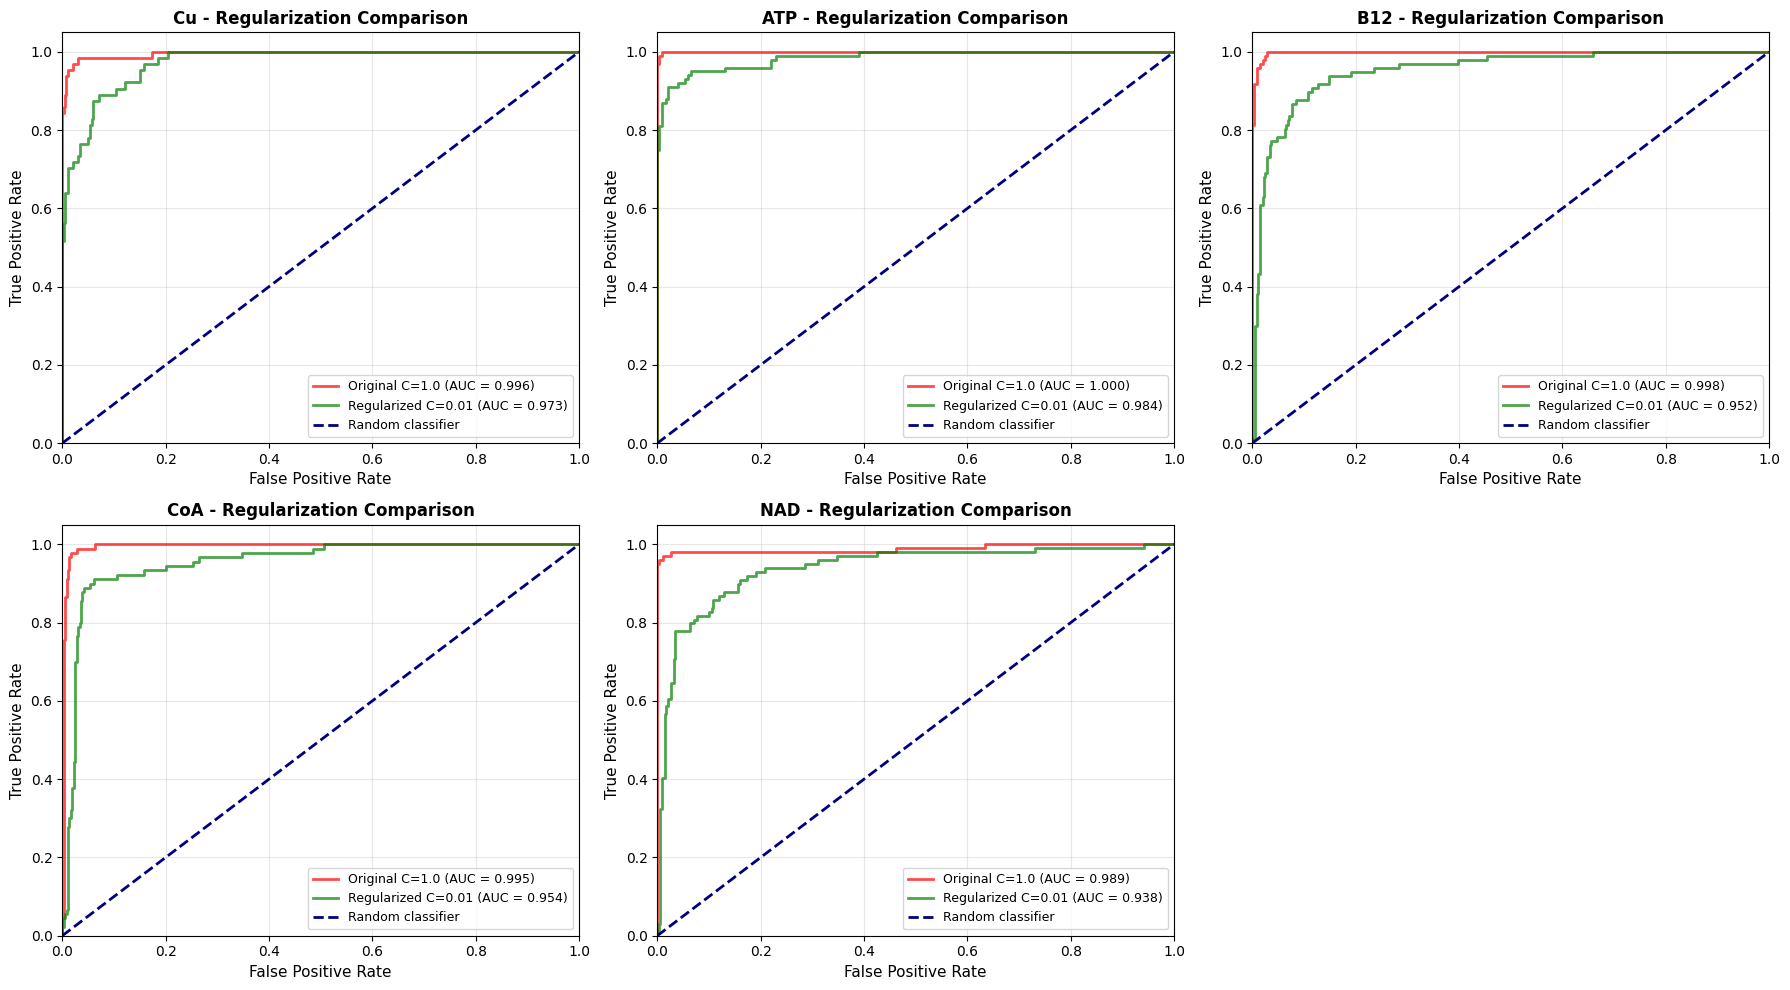


VISUAL INTERPRETATION:
🔴 RED (Original C=1.0): Near-perfect curves suggest overfitting
🟢 GREEN (Regularized C=0.01): More realistic curves, still excellent performance

The green curves show the regularized models still achieve strong
discrimination (AUC > 0.93), confirming the ESM2 embeddings capture
genuine biological signals for cofactor binding, not just memorization.

Recommendation: Use the regularized models (C=0.01) for predictions on new proteins.


In [99]:
# Compare ROC curves: Original vs Regularized models

from sklearn.metrics import roc_curve, auc

n_cofactors = len(cofactor_names)
n_cols = min(3, n_cofactors)
n_rows = int(np.ceil(n_cofactors / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(6*n_cols, 5*n_rows))
if n_cofactors == 1:
    axes = np.array([axes])
axes = axes.flatten()

for idx, cofactor in enumerate(cofactor_names):
    # Original model (C=1.0)
    orig_fpr = roc_data[cofactor]['fpr']
    orig_tpr = roc_data[cofactor]['tpr']
    orig_auc = roc_data[cofactor]['auc']
    
    # Regularized model (C=0.01)
    reg_results = regularized_results[cofactor]
    reg_fpr, reg_tpr, _ = roc_curve(reg_results['y_test'], reg_results['y_proba'])
    reg_auc = auc(reg_fpr, reg_tpr)
    
    # Plot both curves
    axes[idx].plot(orig_fpr, orig_tpr, color='red', lw=2, alpha=0.7,
                   label=f'Original C=1.0 (AUC = {orig_auc:.3f})')
    axes[idx].plot(reg_fpr, reg_tpr, color='green', lw=2, alpha=0.7,
                   label=f'Regularized C=0.01 (AUC = {reg_auc:.3f})')
    axes[idx].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', 
                   label='Random classifier')
    
    axes[idx].set_xlim([0.0, 1.0])
    axes[idx].set_ylim([0.0, 1.05])
    axes[idx].set_xlabel('False Positive Rate', fontsize=11)
    axes[idx].set_ylabel('True Positive Rate', fontsize=11)
    axes[idx].set_title(f'{cofactor} - Regularization Comparison', 
                       fontsize=12, fontweight='bold')
    axes[idx].legend(loc="lower right", fontsize=9)
    axes[idx].grid(alpha=0.3)

# Hide extra subplots
for idx in range(n_cofactors, len(axes)):
    axes[idx].axis('off')

plt.tight_layout()

# Save figure
comparison_path = os.path.join(FIGURES_DIR, "roc_curves_regularization_comparison.png")
plt.savefig(comparison_path, dpi=300, bbox_inches='tight')
print(f"Saved ROC comparison to: {comparison_path}")

plt.show()

print("\n" + "=" * 80)
print("VISUAL INTERPRETATION:")
print("=" * 80)
print("🔴 RED (Original C=1.0): Near-perfect curves suggest overfitting")
print("🟢 GREEN (Regularized C=0.01): More realistic curves, still excellent performance")
print("\nThe green curves show the regularized models still achieve strong")
print("discrimination (AUC > 0.93), confirming the ESM2 embeddings capture")
print("genuine biological signals for cofactor binding, not just memorization.")
print("\nRecommendation: Use the regularized models (C=0.01) for predictions on new proteins.")

## Confusion Matrices for Binary Classifiers

Visualize prediction performance for each cofactor with confusion matrices showing true positives, true negatives, false positives, and false negatives.

Saved confusion matrices to: C:\Users\d_gar\research\code_and_scripts\data_analysis\cofactor_PLM\results\20260512_ncbi_enzyme_cofactor_data\figures\confusion_matrices.png


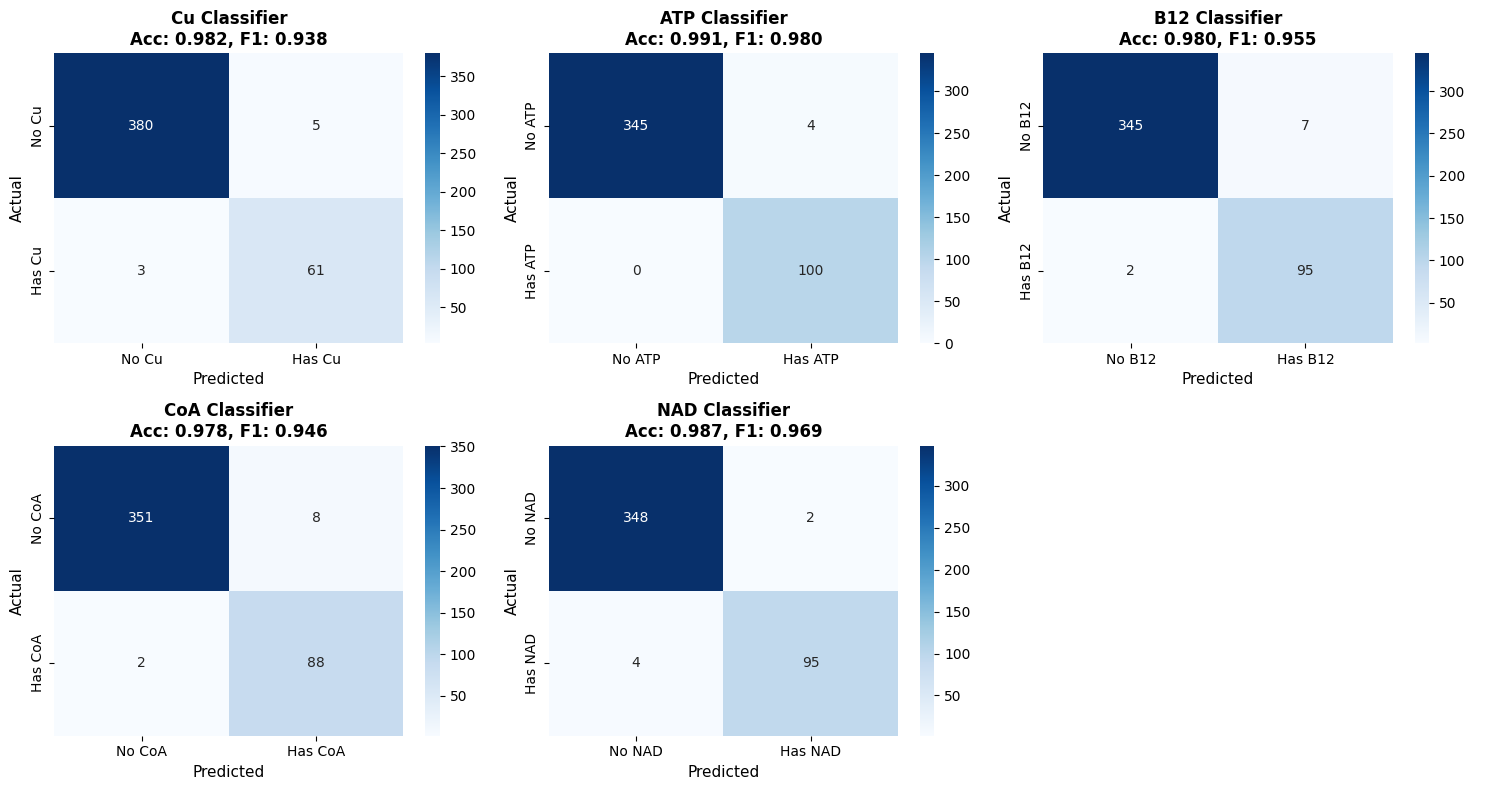


Confusion matrices for all 5 binary classifiers


In [100]:
# Generate confusion matrices for all binary classifiers

n_cofactors = len(cofactor_names)
n_cols = min(3, n_cofactors)
n_rows = int(np.ceil(n_cofactors / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(5*n_cols, 4*n_rows))
if n_cofactors == 1:
    axes = np.array([axes])
axes = axes.flatten()

for idx, cofactor in enumerate(cofactor_names):
    results = binary_results[cofactor]
    cm = confusion_matrix(results['y_test'], results['y_pred'])
    
    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues',
        xticklabels=[f'No {cofactor}', f'Has {cofactor}'],
        yticklabels=[f'No {cofactor}', f'Has {cofactor}'],
        ax=axes[idx],
        cbar=True
    )
    
    axes[idx].set_xlabel('Predicted', fontsize=11)
    axes[idx].set_ylabel('Actual', fontsize=11)
    axes[idx].set_title(f'{cofactor} Classifier\nAcc: {results["accuracy"]:.3f}, F1: {results["f1"]:.3f}', 
                       fontsize=12, fontweight='bold')

# Hide extra subplots if n_cofactors doesn't fill the grid
for idx in range(n_cofactors, len(axes)):
    axes[idx].axis('off')

plt.tight_layout()

# Save figure
confusion_matrix_path = os.path.join(FIGURES_DIR, "confusion_matrices.png")
plt.savefig(confusion_matrix_path, dpi=300, bbox_inches='tight')
print(f"Saved confusion matrices to: {confusion_matrix_path}")

plt.show()

print(f"\nConfusion matrices for all {len(cofactor_names)} binary classifiers")

## ROC Curves for Binary Classifiers

Receiver Operating Characteristic (ROC) curves show the trade-off between true positive rate and false positive rate at various classification thresholds. Area Under Curve (AUC) provides a single metric for classifier performance.

Saved ROC curves to: C:\Users\d_gar\research\code_and_scripts\data_analysis\cofactor_PLM\results\20260512_ncbi_enzyme_cofactor_data\figures\roc_curves.png


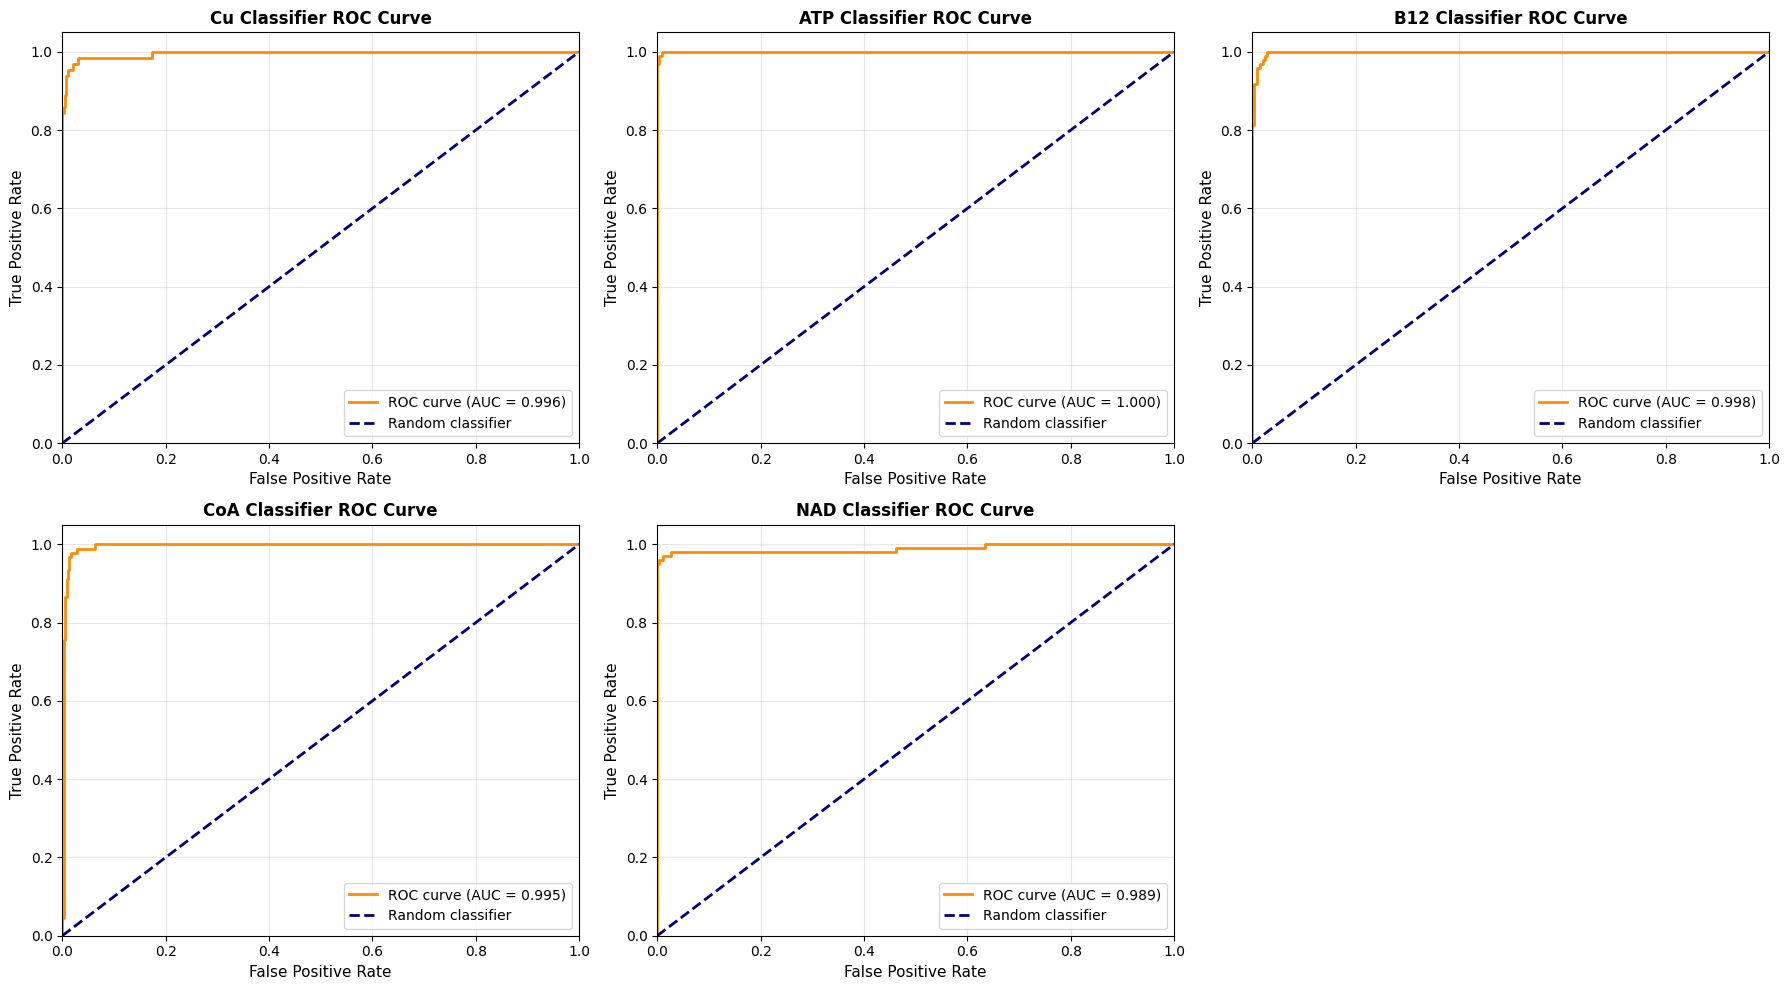


ROC AUC SCORES SUMMARY
Cu: AUC = 0.9957
ATP: AUC = 0.9999
B12: AUC = 0.9984
CoA: AUC = 0.9951
NAD: AUC = 0.9885

Interpretation:
  - AUC = 1.0: Perfect classifier
  - AUC = 0.5: Random classifier (no better than chance)
  - AUC > 0.7: Generally acceptable performance
  - AUC > 0.8: Excellent performance
  - AUC > 0.9: Outstanding performance


In [101]:
# Generate ROC curves for all binary classifiers

from sklearn.metrics import roc_curve, auc, roc_auc_score

n_cofactors = len(cofactor_names)
n_cols = min(3, n_cofactors)
n_rows = int(np.ceil(n_cofactors / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(6*n_cols, 5*n_rows))
if n_cofactors == 1:
    axes = np.array([axes])
axes = axes.flatten()

roc_data = {}

for idx, cofactor in enumerate(cofactor_names):
    results = binary_results[cofactor]
    y_test = results['y_test']
    y_proba = results['y_proba'][:, 1]  # Probability of positive class
    
    # Calculate ROC curve
    fpr, tpr, thresholds = roc_curve(y_test, y_proba)
    roc_auc = auc(fpr, tpr)
    
    # Store ROC data
    roc_data[cofactor] = {
        'fpr': fpr,
        'tpr': tpr,
        'thresholds': thresholds,
        'auc': roc_auc
    }
    
    # Plot ROC curve
    axes[idx].plot(fpr, tpr, color='darkorange', lw=2, 
                   label=f'ROC curve (AUC = {roc_auc:.3f})')
    axes[idx].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', 
                   label='Random classifier')
    axes[idx].set_xlim([0.0, 1.0])
    axes[idx].set_ylim([0.0, 1.05])
    axes[idx].set_xlabel('False Positive Rate', fontsize=11)
    axes[idx].set_ylabel('True Positive Rate', fontsize=11)
    axes[idx].set_title(f'{cofactor} Classifier ROC Curve', 
                       fontsize=12, fontweight='bold')
    axes[idx].legend(loc="lower right", fontsize=10)
    axes[idx].grid(alpha=0.3)

# Hide extra subplots
for idx in range(n_cofactors, len(axes)):
    axes[idx].axis('off')

plt.tight_layout()

# Save figure
roc_curves_path = os.path.join(FIGURES_DIR, "roc_curves.png")
plt.savefig(roc_curves_path, dpi=300, bbox_inches='tight')
print(f"Saved ROC curves to: {roc_curves_path}")

plt.show()

# Print summary
print("\n" + "=" * 80)
print("ROC AUC SCORES SUMMARY")
print("=" * 80)
for cofactor in cofactor_names:
    auc_score = roc_data[cofactor]['auc']
    print(f"{cofactor}: AUC = {auc_score:.4f}")
print("=" * 80)
print("\nInterpretation:")
print("  - AUC = 1.0: Perfect classifier")
print("  - AUC = 0.5: Random classifier (no better than chance)")
print("  - AUC > 0.7: Generally acceptable performance")
print("  - AUC > 0.8: Excellent performance")
print("  - AUC > 0.9: Outstanding performance")

## Feature Importance Analysis

Analyze which features are most important for each cofactor classifier. Features include both ESM2 embedding dimensions (0-319) and engineered sequence properties (320+). Logistic regression coefficients indicate which features contribute most to predictions.

In [102]:
# Extract and rank feature importance for each classifier

feature_importance_summary = {}

# Create feature labels
n_embedding_dims = X_seq.shape[1]
n_engineered_feats = X_features.shape[1]
all_feature_labels = ([f'ESM_{i}' for i in range(n_embedding_dims)] + 
                      [f'Feat_{feature_names[i]}' if i < len(feature_names) else f'Feat_{i}' 
                       for i in range(n_engineered_feats)])

print("=" * 80)
print("TOP 20 MOST IMPORTANT FEATURES FOR EACH COFACTOR CLASSIFIER")
print("=" * 80)
print(f"\nFeatures include:")
print(f"  - ESM2 embeddings (0-{n_embedding_dims-1}): Deep sequence representations")
print(f"  - Engineered features ({n_embedding_dims}-{X_combined.shape[1]-1}): Cofactor-binding signatures")
print("\nPositive coefficients = increase binding likelihood")
print("Negative coefficients = decrease binding likelihood\n")

for cofactor in cofactor_names:
    clf = binary_classifiers[cofactor]
    coefficients = clf.coef_[0]  # All features
    
    # Get absolute values for importance ranking
    abs_coefs = np.abs(coefficients)
    
    # Get top 20 features
    top_indices = np.argsort(abs_coefs)[-20:][::-1]
    top_values = coefficients[top_indices]
    
    feature_importance_summary[cofactor] = {
        'top_indices': top_indices,
        'top_values': top_values,
        'all_coefficients': coefficients
    }
    
    print(f"\n{cofactor} Classifier:")
    print("-" * 80)
    print(f"{'Rank':<6} {'Feature':<35} {'Coefficient':<15} {'Impact'}")
    print("-" * 80)
    
    for rank, (idx, val) in enumerate(zip(top_indices, top_values), 1):
        impact = "Positive +" if val > 0 else "Negative -"
        feat_label = all_feature_labels[idx] if idx < len(all_feature_labels) else f"Feature_{idx}"
        # Truncate long labels
        feat_label = feat_label[:33] + '..' if len(feat_label) > 35 else feat_label
        print(f"{rank:<6} {feat_label:<35} {val:>12.4f}    {impact}")
    
    # Summary statistics
    print("-" * 80)
    print(f"Mean |coefficient|: {np.mean(abs_coefs):.4f}")
    print(f"Max |coefficient|:  {np.max(abs_coefs):.4f}")
    print(f"Std coefficient:    {np.std(coefficients):.4f}")
    
    # Count feature types in top 20
    n_embedding_top = sum(1 for idx in top_indices if idx < n_embedding_dims)
    n_engineered_top = sum(1 for idx in top_indices if idx >= n_embedding_dims)
    print(f"Top 20 breakdown: {n_embedding_top} ESM2, {n_engineered_top} engineered features")

print("\n" + "=" * 80)
print("INTERPRETATION:")
print("=" * 80)
print("- Higher |coefficient| = more important for prediction")
print("- Positive coefficient = feature increases binding probability")
print("- Negative coefficient = feature decreases binding probability")
print("- ESM2 features capture evolutionary/structural patterns")
print("- Engineered features capture explicit cofactor-binding signatures")
print("- Different cofactors rely on different feature combinations")

TOP 20 MOST IMPORTANT FEATURES FOR EACH COFACTOR CLASSIFIER

Features include:
  - ESM2 embeddings (0-319): Deep sequence representations
  - Engineered features (320-372): Cofactor-binding signatures

Positive coefficients = increase binding likelihood
Negative coefficients = decrease binding likelihood


Cu Classifier:
--------------------------------------------------------------------------------
Rank   Feature                             Coefficient     Impact
--------------------------------------------------------------------------------
1      ESM_25                                    1.8890    Positive +
2      ESM_140                                   1.6782    Positive +
3      ESM_24                                   -1.5533    Negative -
4      ESM_89                                    1.5508    Positive +
5      ESM_158                                   1.4980    Positive +
6      ESM_33                                    1.4798    Positive +
7      ESM_126               

Saved feature importance plot to: C:\Users\d_gar\research\code_and_scripts\data_analysis\cofactor_PLM\results\20260512_ncbi_enzyme_cofactor_data\figures\feature_importance.png


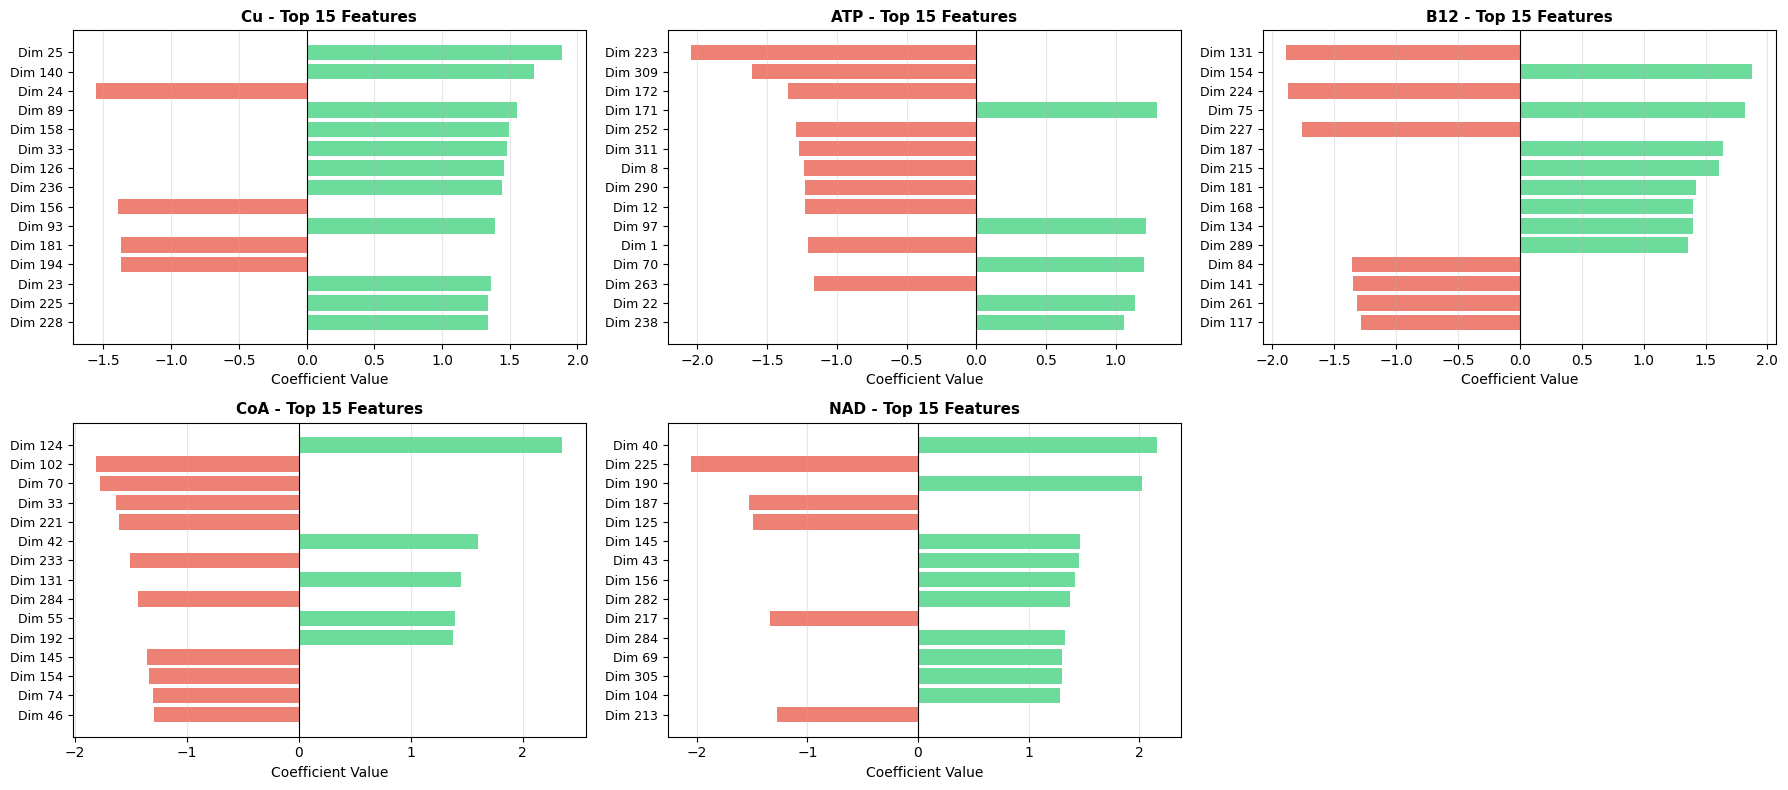


Feature importance visualization for 5 classifiers
Green bars: Positive coefficients (increase binding probability)
Red bars: Negative coefficients (decrease binding probability)


In [103]:
# Visualize feature importance for each classifier

n_cofactors = len(cofactor_names)
n_cols = min(3, n_cofactors)
n_rows = int(np.ceil(n_cofactors / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(6*n_cols, 4*n_rows))
if n_cofactors == 1:
    axes = np.array([axes])
axes = axes.flatten()

for idx, cofactor in enumerate(cofactor_names):
    importance = feature_importance_summary[cofactor]
    top_indices = importance['top_indices'][:15]  # Show top 15
    top_values = importance['top_values'][:15]
    
    colors = ['#2ecc71' if v > 0 else '#e74c3c' for v in top_values]
    
    axes[idx].barh(range(len(top_indices)), top_values, color=colors, alpha=0.7)
    axes[idx].set_yticks(range(len(top_indices)))
    axes[idx].set_yticklabels([f'Dim {i}' for i in top_indices], fontsize=9)
    axes[idx].set_xlabel('Coefficient Value', fontsize=10)
    axes[idx].set_title(f'{cofactor} - Top 15 Features', fontsize=11, fontweight='bold')
    axes[idx].axvline(x=0, color='black', linestyle='-', linewidth=0.8)
    axes[idx].grid(axis='x', alpha=0.3)
    
    # Invert y-axis so most important is on top
    axes[idx].invert_yaxis()

# Hide extra subplots
for idx in range(n_cofactors, len(axes)):
    axes[idx].axis('off')

plt.tight_layout()

# Save figure
feature_importance_path = os.path.join(FIGURES_DIR, "feature_importance.png")
plt.savefig(feature_importance_path, dpi=300, bbox_inches='tight')
print(f"Saved feature importance plot to: {feature_importance_path}")

plt.show()

print(f"\nFeature importance visualization for {len(cofactor_names)} classifiers")
print("Green bars: Positive coefficients (increase binding probability)")
print("Red bars: Negative coefficients (decrease binding probability)")

In [104]:
# Function to predict cofactors for new proteins using binary classifiers

def predict_cofactors_binary(combined_features, classifiers):
    """
    Predict cofactors using the trained classifiers.
    
    Args:
        combined_features: numpy array of shape (n_samples, n_features) 
                          containing ESM embeddings + engineered features
        classifiers: dictionary of trained classifiers
    """
    predictions = {}
    
    for cofactor in cofactor_names:
        clf = classifiers[cofactor]
        y_pred = clf.predict(combined_features)
        y_proba = clf.predict_proba(combined_features)[:, 1]
        
        predictions[f'{cofactor}_prediction'] = y_pred
        predictions[f'{cofactor}_probability'] = y_proba
    
    return pd.DataFrame(predictions)

print("=== EXAMPLE PREDICTIONS ===\n")
test_indices = [0, 2, 4, 10, 15]
test_combined = X_combined[test_indices]  # Use combined features

predictions_df = predict_cofactors_binary(test_combined, binary_classifiers)

predictions_df['protein_id'] = [df.iloc[i]['protein_id'][:40] for i in test_indices]
predictions_df['actual_cofactor'] = [df.iloc[i]['ideal_cofactor'] for i in test_indices]

cols = ['protein_id', 'actual_cofactor'] + [c for c in predictions_df.columns if c not in ['protein_id', 'actual_cofactor']]
predictions_df = predictions_df[cols]

print(predictions_df.to_string())

print("\nPredictions made using ONLY sequence information")
print("  No activity data used - realistic for novel proteins!")

=== EXAMPLE PREDICTIONS ===

                                 protein_id actual_cofactor  Cu_prediction  Cu_probability  ATP_prediction  ATP_probability  B12_prediction  B12_probability  CoA_prediction  CoA_probability  NAD_prediction  NAD_probability
0  NP_013752.1 copper chaperone CCS1 [Sacch              Cu              1        0.947759               0     3.169300e-04               0         0.021220               0         0.112470               0         0.128370
1  WP_415607860.1 copper homeostasis protei              Cu              1        0.999304               0     5.153356e-02               0         0.125781               0         0.000317               0         0.000295
2  CAN5492343.1 copper oxidase [soil metage              Cu              1        0.998599               0     7.900662e-05               0         0.047138               0         0.016263               0         0.032124
3  NP_001004652.1 cytochrome c oxidase copp              Cu              1     

## Save Binary Classifiers

Save trained models and metadata for future use.

In [105]:
# Save binary classifiers and metadata to organized output folder

import pickle

# Prepare artifacts dictionary
binary_artifacts = {
    'classifiers': binary_classifiers,
    'cofactor_names': cofactor_names,
    'feature_importance': feature_importance_summary,
    'roc_data': roc_data,
    'esm_model_name': "esm2_t6_8M_UR50D",
    'embedding_dim': X_seq.shape[1],
    'n_engineered_features': X_features.shape[1],
    'feature_names': feature_names,
    'total_features': X_combined.shape[1],
    'approach': 'binary_classification',
    'features_used': 'esm_embeddings + engineered_sequence_features',
    'data_leakage': False,
    'performance': {
        cf: {
            'accuracy': binary_results[cf]['accuracy'],
            'f1': binary_results[cf]['f1'],
            'auc': roc_data[cf]['auc']
        } for cf in cofactor_names
    },
    'configuration': {
        'seed': SEED,
        'test_size': TEST_SIZE,
        'max_iterations': MAX_ITERATIONS,
        'esm_batch_size': ESM_BATCH_SIZE,
        'esm_repr_layer': ESM_REPR_LAYER,
        'truncate_length': TRUNCATE_LENGTH,
        'remove_none_cofactors': REMOVE_NONE_COFACTORS,
        'data_path': DATA_PATH,
        'timestamp': datetime.now().strftime("%Y-%m-%d %H:%M:%S")
    }
}

# Save to models directory
model_path = os.path.join(MODELS_DIR, "binary_cofactor_classifiers.pkl")
with open(model_path, 'wb') as f:
    pickle.dump(binary_artifacts, f)

print("=" * 80)
print("MODEL ARTIFACTS SAVED")
print("=" * 80)
print(f"Model file: {model_path}")
print("\nArtifacts include:")
print(f"  - {len(cofactor_names)} binary classifiers (one per cofactor)")
print(f"  - Cofactor names: {', '.join(cofactor_names)}")
print(f"  - Feature importance for each classifier")
print(f"  - ROC curve data (AUC scores)")
print(f"  - Configuration parameters (seed={SEED})")
print("  - ESM model info: esm2_t6_8M_UR50D")
print(f"  - Total features: {X_combined.shape[1]} ({X_seq.shape[1]} ESM + {X_features.shape[1]} engineered)")
print("  - Confirmed: No data leakage")
print("\n" + "=" * 80)
print("PERFORMANCE SUMMARY")
print("=" * 80)
for cofactor in cofactor_names:
    perf = binary_artifacts['performance'][cofactor]
    print(f"{cofactor}:")
    print(f"  Accuracy: {perf['accuracy']:.4f}")
    print(f"  F1 Score: {perf['f1']:.4f}")
    print(f"  AUC:      {perf['auc']:.4f}")
print("=" * 80)
print("\nTo use on new proteins:")
print("  1. Generate ESM embeddings from sequence")
print("  2. Engineer same sequence features (AA comp, metal motifs, etc.)")
print("  3. Combine embeddings + features")
print("  4. Load classifiers with pickle.load()")
print("  5. Call predict() on each binary classifier")
print("  6. Get yes/no prediction + probability for each cofactor")
print(f"\nAll outputs saved to: {OUTPUT_FOLDER}")

MODEL ARTIFACTS SAVED
Model file: C:\Users\d_gar\research\code_and_scripts\data_analysis\cofactor_PLM\results\20260512_ncbi_enzyme_cofactor_data\models\binary_cofactor_classifiers.pkl

Artifacts include:
  - 5 binary classifiers (one per cofactor)
  - Cofactor names: Cu, ATP, B12, CoA, NAD
  - Feature importance for each classifier
  - ROC curve data (AUC scores)
  - Configuration parameters (seed=42)
  - ESM model info: esm2_t6_8M_UR50D
  - Total features: 373 (320 ESM + 53 engineered)
  - Confirmed: No data leakage

PERFORMANCE SUMMARY
Cu:
  Accuracy: 0.9822
  F1 Score: 0.9385
  AUC:      0.9957
ATP:
  Accuracy: 0.9911
  F1 Score: 0.9804
  AUC:      0.9999
B12:
  Accuracy: 0.9800
  F1 Score: 0.9548
  AUC:      0.9984
CoA:
  Accuracy: 0.9777
  F1 Score: 0.9462
  AUC:      0.9951
NAD:
  Accuracy: 0.9866
  F1 Score: 0.9694
  AUC:      0.9885

To use on new proteins:
  1. Generate ESM embeddings from sequence
  2. Engineer same sequence features (AA comp, metal motifs, etc.)
  3. Combine

## Predict Cofactors for New Sequences

Use the trained models to predict cofactor binding for new protein sequences. Simply provide a list of FASTA sequences below and the models will generate predictions with probabilities for each cofactor.

In [106]:
# ===== INPUT YOUR SEQUENCES HERE =====
# Add your FASTA sequences to the list below
# Each entry should be a dictionary with 'id' and 'sequence' keys

NEW_SEQUENCES = [
    # Example sequences (replace with your own):
    # {
    #     'id': 'Protein_1',
    #     'sequence': 'MKTIIALSYIFCLVFADYKDDDDK...'
    # },
    # {
    #     'id': 'Protein_2',
    #     'sequence': 'MKKLILSAIFLLSSFSALVKPSSK...'
    # }
]

# ===== PREDICTION CODE =====

if len(NEW_SEQUENCES) == 0:
    print("=" * 80)
    print("NO SEQUENCES PROVIDED")
    print("=" * 80)
    print("\nTo make predictions:")
    print("1. Add your sequences to the NEW_SEQUENCES list above")
    print("2. Each sequence should be a dictionary with 'id' and 'sequence' keys")
    print("3. Run this cell again")
    print("\nExample format:")
    print("NEW_SEQUENCES = [")
    print("    {'id': 'MyProtein1', 'sequence': 'MKTIIALSYIF...'},")
    print("    {'id': 'MyProtein2', 'sequence': 'MKKLILSAIFL...'},")
    print("]")
else:
    print("=" * 80)
    print(f"PREDICTING COFACTORS FOR {len(NEW_SEQUENCES)} NEW SEQUENCES")
    print("=" * 80)
    
    # Extract sequences and IDs
    new_ids = [seq['id'] for seq in NEW_SEQUENCES]
    new_seqs = [seq['sequence'] for seq in NEW_SEQUENCES]
    
    # Clean sequences
    VALID_AA = set(list("ACDEFGHIKLMNPQRSTVWYUXBZJO"))
    def clean_sequence(seq: str) -> str:
        seq = str(seq).strip().upper()
        seq = seq.replace(" ", "")
        seq = "".join([aa for aa in seq if aa in VALID_AA])
        return seq
    
    new_seqs_cleaned = [clean_sequence(seq) for seq in new_seqs]
    
    print(f"\n1. Generating ESM2 embeddings for {len(new_seqs_cleaned)} sequences...")
    
    # Generate embeddings
    new_embeddings = embed_sequences_esm(
        sequences=new_seqs_cleaned,
        ids=new_ids,
        batch_size=ESM_BATCH_SIZE,
        repr_layer=ESM_REPR_LAYER
    )
    
    print(f"   ✓ Embeddings generated: {new_embeddings.shape}")
    
    # Generate engineered features for new sequences
    print(f"\n2. Engineering sequence features for cofactor binding...")
    
    new_feature_list = []
    for seq in tqdm(new_seqs_cleaned, desc="Extracting features"):
        features = []
        seq_len = len(seq)
        
        # Same feature engineering as training
        features.append(seq_len / 1000.0)  # Length
        
        # AA composition
        aa_standard = 'ACDEFGHIKLMNPQRSTVWY'
        for aa in aa_standard:
            features.append(seq.count(aa) / seq_len)
        
        # Amino acid groups
        aa_groups = {
            'hydrophobic': 'AILMFWYV', 'polar': 'STNQ', 'positive': 'KR',
            'negative': 'DE', 'aromatic': 'FWY', 'aliphatic': 'ILV',
            'small': 'AGSV', 'tiny': 'AGS', 'metal_coord': 'HCDE',
            'cysteine': 'C', 'histidine': 'H', 'aspartate': 'D',
            'glutamate': 'E', 'methionine': 'M', 'tyrosine': 'Y', 'tryptophan': 'W'
        }
        for group_aas in aa_groups.values():
            features.append(sum(seq.count(aa) for aa in group_aas) / seq_len)
        
        # Metal binding motifs
        cxxc = sum(1 for i in range(len(seq) - 3) if seq[i] == 'C' and seq[i+3] == 'C')
        hxxh = sum(1 for i in range(len(seq) - 3) if seq[i] == 'H' and seq[i+3] == 'H')
        cc_count = seq.count('CC')
        features.extend([
            cxxc / max(1, seq_len - 3),
            hxxh / max(1, seq_len - 3),
            cc_count / max(1, seq_len - 1)
        ])
        
        # Charge properties
        positive_count = sum(seq.count(aa) for aa in 'KR')
        negative_count = sum(seq.count(aa) for aa in 'DE')
        features.extend([
            (positive_count - negative_count) / seq_len,  # net charge
            (positive_count + negative_count) / seq_len   # charge density
        ])
        
        # Hydrophobicity, MW, aromatic clusters
        hydrophobic = sum(seq.count(aa) for aa in 'AILMFWYV')
        hydrophilic = sum(seq.count(aa) for aa in 'RKDENQ')
        features.append((hydrophobic - hydrophilic) / seq_len)  # GRAVY
        features.append(seq_len * 110 / 50000)  # MW estimate
        
        aromatic_cluster = sum(1 for i in range(len(seq) - 2) 
                              if sum(aa in 'FWY' for aa in seq[i:i+3]) >= 2)
        features.append(aromatic_cluster / max(1, seq_len - 2))
        
        # Metal hotspots
        metal_hotspots = sum(1 for i in range(len(seq) - 9)
                            if sum(aa in 'HCDE' for aa in seq[i:i+10]) >= 4)
        features.append(metal_hotspots / max(1, seq_len - 9))
        
        # Redox residues, cysteine count, disulfide potential
        features.append((seq.count('C') + seq.count('M')) / seq_len)
        cys_count = seq.count('C')
        features.append(cys_count)
        features.append(1 if cys_count % 2 == 0 and cys_count > 0 else 0)
        
        # Proline and glycine
        features.extend([seq.count('P') / seq_len, seq.count('G') / seq_len])
        
        # Terminal features
        n_term = seq[:min(20, seq_len)]
        c_term = seq[-min(20, seq_len):]
        features.append(sum(aa in 'HCDE' for aa in n_term) / len(n_term))
        features.append(sum(aa in 'HCDE' for aa in c_term) / len(c_term))
        
        new_feature_list.append(features)
    
    new_features = np.array(new_feature_list)
    
    # Standardize using the same scaler from training
    from sklearn.preprocessing import StandardScaler
    new_features_scaled = feature_data['scaler'].transform(new_features)
    
    print(f"   ✓ Engineered features: {new_features_scaled.shape}")
    
    # Combine embeddings with features
    print(f"\n3. Combining embeddings + engineered features...")
    new_combined = np.hstack([new_embeddings, new_features_scaled])
    print(f"   ✓ Combined feature matrix: {new_combined.shape}")
    
    # Make predictions with all classifiers
    print(f"\n4. Making predictions with binary classifiers...")
    
    predictions_dict = {'protein_id': new_ids}
    
    for cofactor in cofactor_names:
        clf = binary_classifiers[cofactor]
        y_pred = clf.predict(new_combined)  # Use combined features
        y_proba = clf.predict_proba(new_combined)[:, 1]
        
        predictions_dict[f'{cofactor}_prediction'] = ['Yes' if p == 1 else 'No' for p in y_pred]
        predictions_dict[f'{cofactor}_probability'] = y_proba
    
    # Create DataFrame
    predictions_df = pd.DataFrame(predictions_dict)
    
    # Save predictions to file
    timestamp_str = datetime.now().strftime("%Y%m%d_%H%M%S")
    predictions_file = os.path.join(PREDICTIONS_DIR, f"predictions_{timestamp_str}.csv")
    predictions_df.to_csv(predictions_file, index=False)
    
    print("\n" + "=" * 80)
    print("PREDICTIONS COMPLETE")
    print("=" * 80)
    print(f"Saved to: {predictions_file}")
    print("\nPredictions:")
    print("=" * 80)
    
    # Display predictions in a readable format
    for i, protein_id in enumerate(new_ids):
        print(f"\n{protein_id}:")
        print(f"  Sequence length: {len(new_seqs_cleaned[i])} amino acids")
        print(f"  Predicted cofactors:")
        
        for cofactor in cofactor_names:
            pred = predictions_df.loc[i, f'{cofactor}_prediction']
            prob = predictions_df.loc[i, f'{cofactor}_probability']
            print(f"    {cofactor}: {pred} (probability: {prob:.3f})")
    
    print("\n" + "=" * 80)
    print("\nFull predictions table:")
    print(predictions_df.to_string(index=False))
    
    print("\n" + "=" * 80)
    print(f"Predictions saved to: {predictions_file}")
    print(f"All results in: {OUTPUT_FOLDER}")

NO SEQUENCES PROVIDED

To make predictions:
1. Add your sequences to the NEW_SEQUENCES list above
2. Each sequence should be a dictionary with 'id' and 'sequence' keys
3. Run this cell again

Example format:
NEW_SEQUENCES = [
    {'id': 'MyProtein1', 'sequence': 'MKTIIALSYIF...'},
    {'id': 'MyProtein2', 'sequence': 'MKKLILSAIFL...'},
]
